In [1]:
import build as neat
from build.util.datetime import eta, clock
from numba.typed import List, Dict
from torch import Tensor
from numba import njit, objmode, prange
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import torch

# Given tensor and list
tensor = torch.tensor([1, 2, 3, 4, 5, 6])
lst = [2, 4, 6]

# Use torch.isin() to check which elements in the tensor are in the list
mask = torch.isin(tensor, torch.tensor(lst))

# Use nonzero() to get the indices and convert them to a list
indices = mask.nonzero(as_tuple=True)[0].tolist()

print(indices)

[1, 3, 5]


In [3]:
DEVICE = torch.device('cuda')
DTYPE  = torch.float32

In [4]:
config = neat.Config("mutation_testing")
config.save()
config.load(verbose=2)

Created configuration 'GENERAL CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Created configuration 'GENOME CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Created configuration 'SPECIES CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Created configuration 'STAGNATION CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Created configuration 'REPRODUCTION CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Loaded configuration 'GENERAL CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Loaded configuration 'GENOME CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Loaded configuration 'SPECIES CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Loaded configuration 'STAGNATION CONFIG' in NEAT Configuration mutation_testing-neat_config.txt
Loaded configuration 'REPRODUCTION CONFIG' in NEAT Configuration mutation_testing-neat_config.txt


In [5]:
POPULATION_SIZE = 100
genomes: dict[int, neat.Genome] = Dict([(i, neat.Genome(i)) for i in range(POPULATION_SIZE)])
genomes[0]

In [25]:
BIAS = False
EMBED_SIZE = 8
PRIMARY = nn.Identity()

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.layers = nn.ModuleList([
            neat.models.main.Linear(1, EMBED_SIZE, BIAS, DEVICE, DTYPE, PRIMARY, False),
            neat.models.main.Linear(EMBED_SIZE, EMBED_SIZE, BIAS, DEVICE, DTYPE, PRIMARY, False),
            neat.models.main.Linear(EMBED_SIZE, EMBED_SIZE, BIAS, DEVICE, DTYPE, PRIMARY, False),
            neat.models.main.Linear(EMBED_SIZE, 1, BIAS, DEVICE, DTYPE, None, False),
        ])

    def forward(self, tensor: Tensor, verbose: int = None):
        # tensor = tensor + 1
        for layer in self.layers:
            tensor = layer(tensor)
            if verbose and verbose >= 1:
                print(f"tensor =>\n{tensor[..., -1, :]}")
        return tensor

    def get_modules(self):
        return [m for m in self.layers]

model = Model()
modules = model.get_modules()

In [26]:
neat.bind_modules(modules, genomes, 3)
model.eval()
model


for a 1 input and 8 output module
created neat-module-4 networks in 0.00s
got neat-module-4 build in 0.00s, got neat-module-4 values in 0.00s
binding modules: progress=25% eta=0sec
for a 8 input and 8 output module
created neat-module-5 networks in 0.00s
got neat-module-5 build in 0.00s, got neat-module-5 values in 0.00s
binding modules: progress=50% eta=0sec
for a 8 input and 8 output module
created neat-module-6 networks in 0.00s
got neat-module-6 build in 0.00s, got neat-module-6 values in 0.00s
binding modules: progress=75% eta=0sec
for a 8 input and 1 output module
created neat-module-7 networks in 0.00s
got neat-module-7 build in 0.00s, got neat-module-7 values in 0.00s
bound modules in 0.02sess=100% eta=0sec


Model(
  (layers): ModuleList(
    (0): Linear(NeatModule)(g=100, in=1, out=8, bias=False, actv=Identity())
    (1-2): 2 x Linear(NeatModule)(g=100, in=8, out=8, bias=False, actv=Identity())
    (3): Linear(NeatModule)(g=100, in=8, out=1, bias=False, actv=None)
  )
)

In [27]:
# inputs = torch.tensor(
#     [[0, 0],
#      [0, 1],
#      [1, 0],
#      [1, 1]], device=DEVICE, dtype=DTYPE
# ).unsqueeze(1).expand(4, len(genomes), 2)
# outputs = torch.tensor(
#     [[0],
#      [1],
#      [1],
#      [0]], device=DEVICE, dtype=DTYPE
# ).unsqueeze(1).expand(4, len(genomes), 1)
inp_num = 10
inputs = torch.arange(-inp_num // 2, inp_num // 2, device=DEVICE, dtype=DTYPE
).reshape(inp_num, 1).unsqueeze(1).expand(inp_num, len(genomes), 1)
outputs = inputs * 3
inputs.shape, outputs.shape

(torch.Size([10, 100, 1]), torch.Size([10, 100, 1]))

In [28]:
inputs[:, 0, 0], outputs[:, 0, 0]

(tensor([-5., -4., -3., -2., -1.,  0.,  1.,  2.,  3.,  4.], device='cuda:0'),
 tensor([-15., -12.,  -9.,  -6.,  -3.,   0.,   3.,   6.,   9.,  12.],
        device='cuda:0'))

In [29]:
model(inputs, verbose=True)[:, 0, 0].detach().cpu()

tensor =>
tensor([[-0.5818,  2.9291,  7.9507,  7.2369,  2.2552, -0.4231, -7.9141,  3.8174],
        [-0.4654,  2.3433,  6.3606,  5.7895,  1.8042, -0.3385, -6.3313,  3.0539],
        [-0.3491,  1.7575,  4.7704,  4.3421,  1.3531, -0.2538, -4.7485,  2.2904],
        [-0.2327,  1.1716,  3.1803,  2.8948,  0.9021, -0.1692, -3.1656,  1.5270],
        [-0.1164,  0.5858,  1.5901,  1.4474,  0.4510, -0.0846, -1.5828,  0.7635],
        [ 0.0000, -0.0000, -0.0000, -0.0000, -0.0000,  0.0000,  0.0000, -0.0000],
        [ 0.1164, -0.5858, -1.5901, -1.4474, -0.4510,  0.0846,  1.5828, -0.7635],
        [ 0.2327, -1.1716, -3.1803, -2.8948, -0.9021,  0.1692,  3.1656, -1.5270],
        [ 0.3491, -1.7575, -4.7704, -4.3421, -1.3531,  0.2538,  4.7485, -2.2904],
        [ 0.4654, -2.3433, -6.3606, -5.7895, -1.8042,  0.3385,  6.3313, -3.0539]],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor =>
tensor([[ 10.5792, -10.8473,  22.0815,  -7.6479,   3.8094,  -8.5678, -12.9828,
          -1.3370],
        [ 

tensor([-231.4754, -185.1804, -138.8853,  -92.5902,  -46.2951,    0.0000,
          46.2951,   92.5902,  138.8853,  185.1804])

In [30]:
structure_ = (
    config.genome.single_structural_mutation,
    config.genome.node_add_prob, config.genome.node_del_prob,
    config.genome.conn_add_prob, config.genome.conn_del_prob,
)
weight_ = (
    config.genome.weight_mutate_rate, config.genome.weight_mutate_power,
    config.genome.weight_min_value, config.genome.weight_max_value,
    config.genome.weight_replace_rate, config.genome.init_type,
    config.genome.weight_init_mean, config.genome.weight_init_std,
)
bias_ = (
    config.genome.bias_mutate_rate, config.genome.bias_mutate_power,
    config.genome.bias_min_value, config.genome.bias_max_value,
    config.genome.bias_replace_rate, config.genome.init_type,
    config.genome.bias_init_mean, config.genome.bias_init_std,
)
params_ = (structure_, weight_, bias_)
params_

((False, 0.2, 0.2, 0.5, 0.5),
 (0.5, 0.0005, -3.14, 3.14, 0.15, 'normal', 0.0, 1.0),
 (0.4, 0.0005, -3.14, 3.14, 0.15, 'normal', 0.0, 1.0))

In [31]:
def get_weights():
    return [param.clone() for param in model.parameters()]

def get_grads(current: list[Tensor], previous: list[Tensor]):
    return [pc - pp for pc, pp in zip(current, previous)]

In [32]:
def get_loss():
    predictions = model(inputs)
    loss = torch.mean((outputs - predictions) ** 2, dim=(0, 2))
    return loss
get_loss()

tensor([1.5933e+04, 9.3055e+02, 1.1405e+03, 3.9719e+03, 1.8802e+03, 6.6442e+03,
        6.7728e+03, 1.4308e+00, 8.6928e+03, 1.7614e+03, 9.1275e+03, 1.8995e+03,
        4.1647e+03, 5.6301e+02, 7.4834e+01, 2.0765e+02, 3.6349e+02, 6.6482e+03,
        1.3984e+04, 1.0644e+03, 6.1131e+02, 3.2717e+02, 1.0245e+03, 2.6152e+03,
        6.3970e+01, 2.7581e+03, 6.5092e+01, 2.3656e+02, 1.1349e+03, 4.0299e+01,
        6.2644e+03, 2.0229e+03, 1.6509e+02, 1.5995e+03, 7.2547e+03, 2.6662e+04,
        2.5489e+03, 9.0385e+03, 1.5830e+04, 5.7940e+02, 7.6362e+01, 6.1564e+03,
        5.5241e+03, 1.3168e+03, 7.5090e+02, 1.0158e+03, 6.8179e+01, 2.1371e+01,
        5.9180e+02, 5.4581e+03, 3.8558e+02, 3.1914e+02, 1.2891e+03, 4.4411e+02,
        3.1247e+02, 4.9287e+03, 4.3034e+02, 4.6547e+01, 5.1179e+01, 3.1561e+01,
        9.7020e+00, 1.8820e+03, 4.0224e+03, 6.6380e+02, 8.6830e+03, 9.0484e+01,
        5.5294e+02, 1.4980e+00, 1.4831e+04, 7.0545e+03, 1.5729e+02, 9.9501e+01,
        7.6186e+02, 3.7153e+02, 7.3778e+

In [33]:
def evaluate(population: dict[int, neat.Genome]):
    with torch.no_grad():
        scores = (-get_loss()).detach().cpu().numpy()
        for genome, score in zip(population.values(), scores):
            genome.fitness = score

@njit(nogil=True)
def breed(population: dict[int, neat.Genome], params: tuple, elitism=0.10):
    def sort_value(members: list[neat.Genome]):
        sorting: list[neat.Genome] = List(members)
        # Selection Sort
        for i in range(len(sorting)):
            max_idx = i
            for j in range(i + 1, len(sorting)):
                if sorting[j].fitness > sorting[max_idx].fitness:
                    max_idx = j
                elif sorting[j].fitness == sorting[max_idx].fitness and sorting[j].key == sorting[max_idx].key:
                    max_idx = j

            # Swap the found maximum element with the first element
            sorting[i], sorting[max_idx] = sorting[max_idx], sorting[i]
        return sorting
    def sort_key(members: list[neat.Genome]):
        sorting: list[neat.Genome] = List(members)
        # Selection Sort
        for i in range(len(sorting)):
            max_idx = i
            for j in range(i + 1, len(sorting)):
                if sorting[j].key > sorting[max_idx].key:
                    max_idx = j
                elif sorting[j].key == sorting[max_idx].key:
                    raise ValueError(f"same keys between genomes")

            # Swap the found maximum element with the first element
            sorting[i], sorting[max_idx] = sorting[max_idx], sorting[i]
        return sorting

    old_members: list[neat.Genome] = sort_value(List(population.values()))
    new_members: list[neat.Genome] = List.empty_list(neat.species.GENOME)

    # return elite
    cutoff = int(max(0, np.ceil(len(population) * elitism)))
    for member in old_members[:cutoff]:
        new_members.append(member)

    # breed new generation
    spawn = int(max(0, np.floor(len(population) * (1-elitism))))
    new_key = sort_key(old_members)[0].key + 1
    filtered_members = old_members[:cutoff]
    members_indexes = np.array([i for i in range(len(filtered_members))])
    s, w, b = params
    for _ in range(spawn):
        parent1 = old_members[np.random.choice(members_indexes)] # p=probs)
        parent2 = old_members[np.random.choice(members_indexes)]

        gid = new_key
        new_key += 1
        child = neat.Genome(gid)
        child.update_from_crossover(parent1, parent2)
        child.mutate(*s, w, b)

        new_members.append(child)

    for idx in prange(len(old_members)):
        member = old_members[idx]
        del population[member.key]
    for idx in prange(len(new_members)):
        member = new_members[idx]
        if member.key in population:
            raise ValueError(f"key already in population")
        population[member.key] = member

In [34]:
def get_stats(buffer: list[list[Tensor]], functions: list = None):
    def max(tensor: Tensor):
        return torch.max(torch.abs(tensor))
    def min(tensor: Tensor):
        tensor = tensor[tensor != 0]
        return torch.min(torch.abs(tensor))
    if functions is None:
        functions = [torch.mean, torch.std, max, min]
    return [
        torch.stack([
            func(torch.cat([torch.flatten(t) for t in grads]))
            for grads in buffer
            # for func in functions
        ])
        for func in functions
        # for grads in buffer
    ]

In [35]:
stats_num = 0
def run():
    global stats_num
    weights = []
    grads = []
    losses = []
    rates = []
    epochs = 1000 - 1
    min_loss = None
    save_state = model.state_dict()
    ts = clock.perf_counter()
    ud = 0
    scheduler = neat.scheduler.CosineAnnealing(config, epochs, 200, 0.5, False)
    nan_tensor = get_weights()
    for t in nan_tensor:
        t[:] = torch.nan
    for state in range(epochs):
        evaluate(genomes)
        breed(genomes, params_, 0.10)
        neat.bind_modules(modules, genomes)
        weights.append(get_weights())
        grads.append(nan_tensor if len(weights) <= 1 else get_grads(get_weights(), weights[-2]))
        loss = get_loss().min()
        losses.append(loss)
        if min_loss is None or loss.item() < min_loss:
            save_state = model.state_dict()
        scheduler.step()
        rates.append(config.genome.weight_mutate_power)
        eta(ts, state+1, epochs, "mutating genomes")
    print(f"\rmutated genomes in {round(clock.perf_counter() - ts, 2)}s                       ")
    model.load_state_dict(save_state)
    best_genome = list(genomes.values())[0]
    print(model(inputs)[:, 0].detach().cpu(), best_genome.key, best_genome.fitness)
    stats = get_stats(grads)
    stats_num = len(stats)
    return stats, losses, rates

In [36]:
INCH_PER_PIXEL = 0.01

def plot(statistics: list[Tensor], labels: list[str] = None, column_axes=1, height=720, width=1080, log_scale=False):
    if labels is None:
        labels = [f"stat {i+1}" for i in range(len(statistics))]
    if len(statistics) == stats_num:
        statistics.append(torch.stack(losses))
        statistics.append(torch.tensor(np.array(rates)))
    labels.append('loss')
    labels.append('rates')
    row_axes = int(np.ceil(len(statistics) / column_axes))
    fig, axes = plt.subplots(row_axes, column_axes, figsize=(width*INCH_PER_PIXEL, height*INCH_PER_PIXEL))
    # print(axes.flatten())
    for axis, stat, title in zip(axes.flatten()[:len(statistics)], statistics, labels):
        stat = stat.detach().cpu().numpy()
        if log_scale and title in ['rates', 'loss']:
            stat = np.log10(stat)
        axis.plot(stat)
        axis.set_title(title)
        # if title == 'loss':
        #     axis.set_ylim(stat.min() * 0.85, stat.mean()) # +(stat.std()/0.5))
    plt.show()
    plt.close(fig)

mutated genomes in 35.71s                       
tensor([[-15.0012],
        [-12.0010],
        [ -9.0007],
        [ -6.0005],
        [ -3.0002],
        [  0.0000],
        [  3.0002],
        [  6.0005],
        [  9.0007],
        [ 12.0010]]) 281988 -5.004885110793111e-07


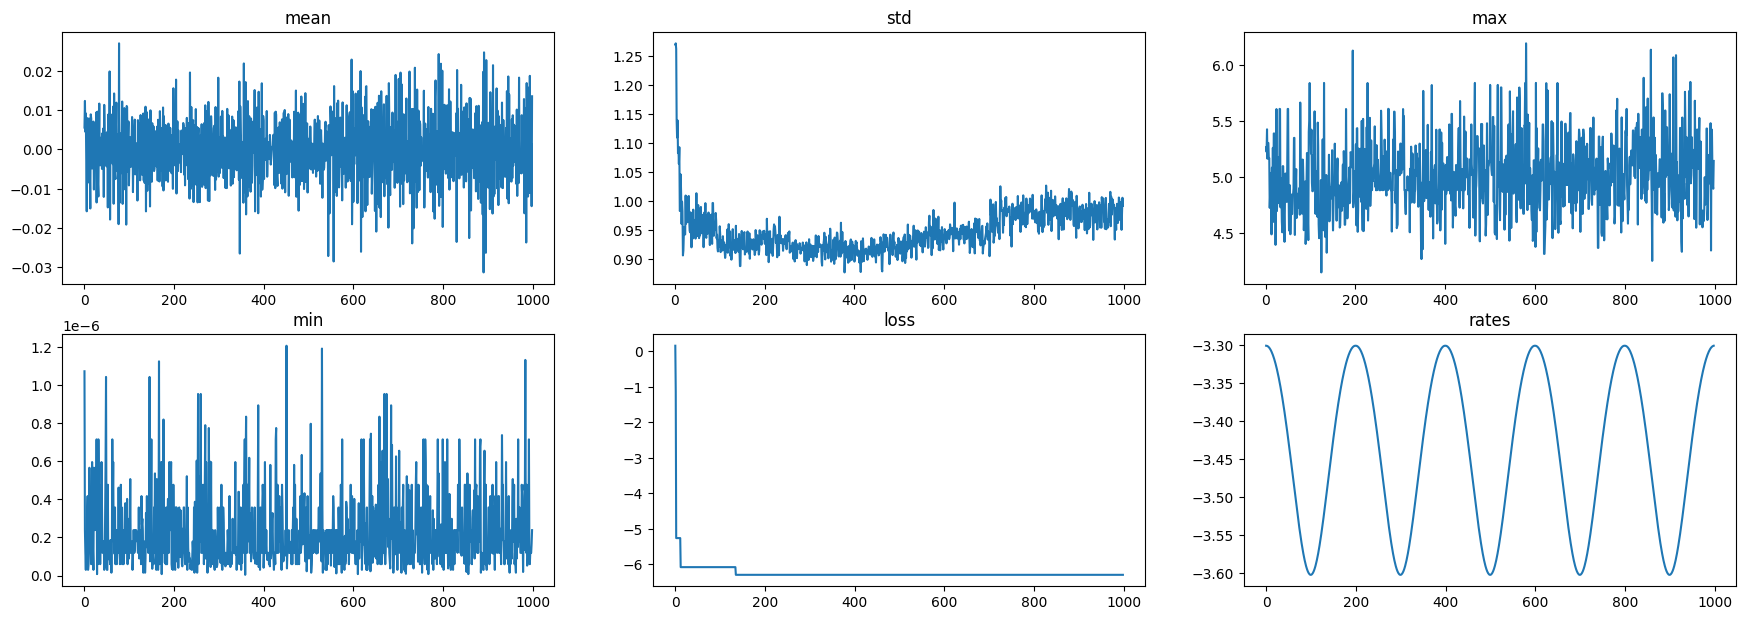

In [37]:
stats, losses, rates = run()
plot(stats, ['mean', 'std', 'max', 'min'], 3, 720, 2160, True)

mutated genomes in 31.99s                       
tensor([[-14.9998],
        [-11.9998],
        [ -8.9999],
        [ -5.9999],
        [ -3.0000],
        [  0.0000],
        [  3.0000],
        [  5.9999],
        [  8.9999],
        [ 11.9998]]) 396551 -2.029455536955993e-08


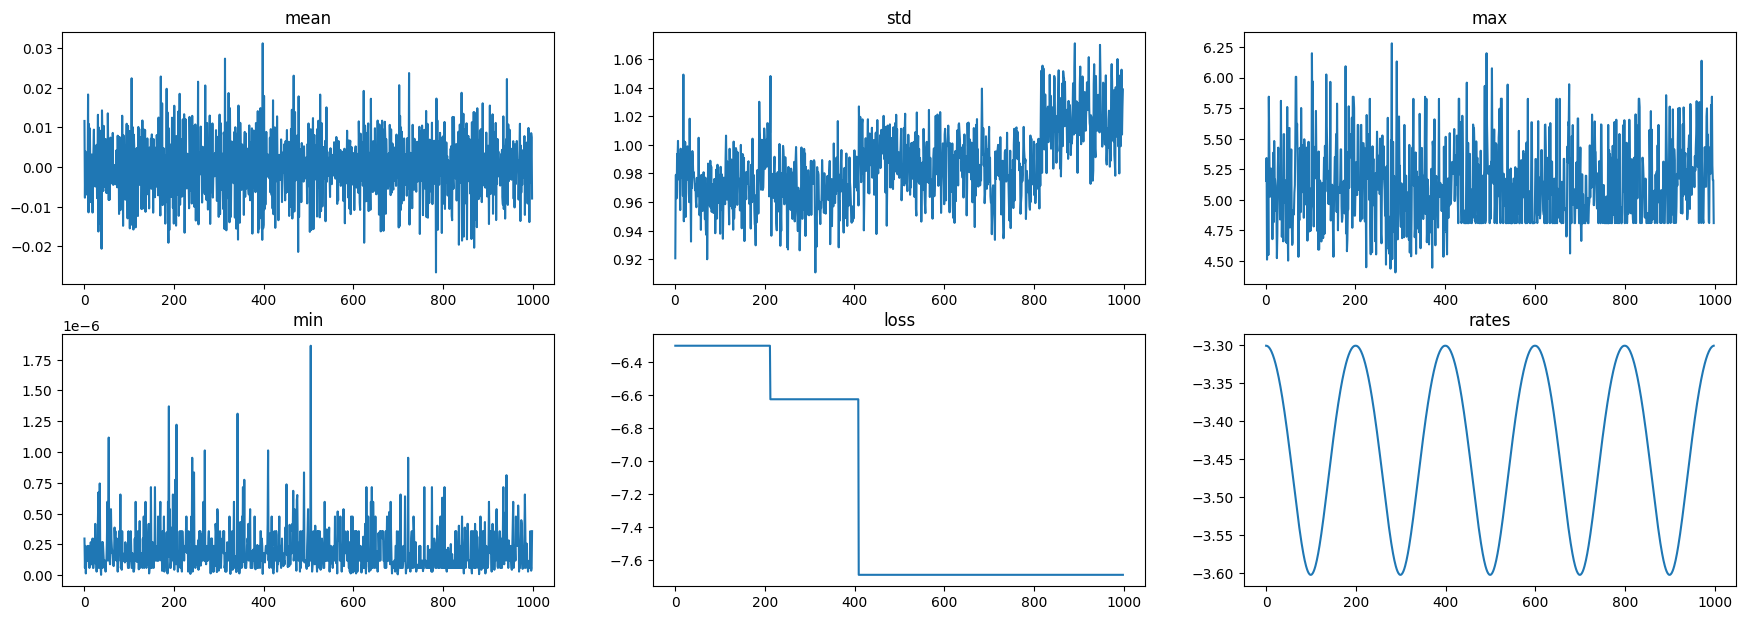

In [38]:
stats, losses, rates = run()
plot(stats, ['mean', 'std', 'max', 'min'], 3, 720, 2160, True)

In [39]:
config.genome.weight_mutate_power = 0.0005
config.genome.bias_mutate_power   = 0.0005

mutated genomes in 32.07s                       
tensor([[-14.9998],
        [-11.9998],
        [ -8.9999],
        [ -5.9999],
        [ -3.0000],
        [  0.0000],
        [  3.0000],
        [  5.9999],
        [  8.9999],
        [ 11.9998]]) 396551 -2.029455536955993e-08


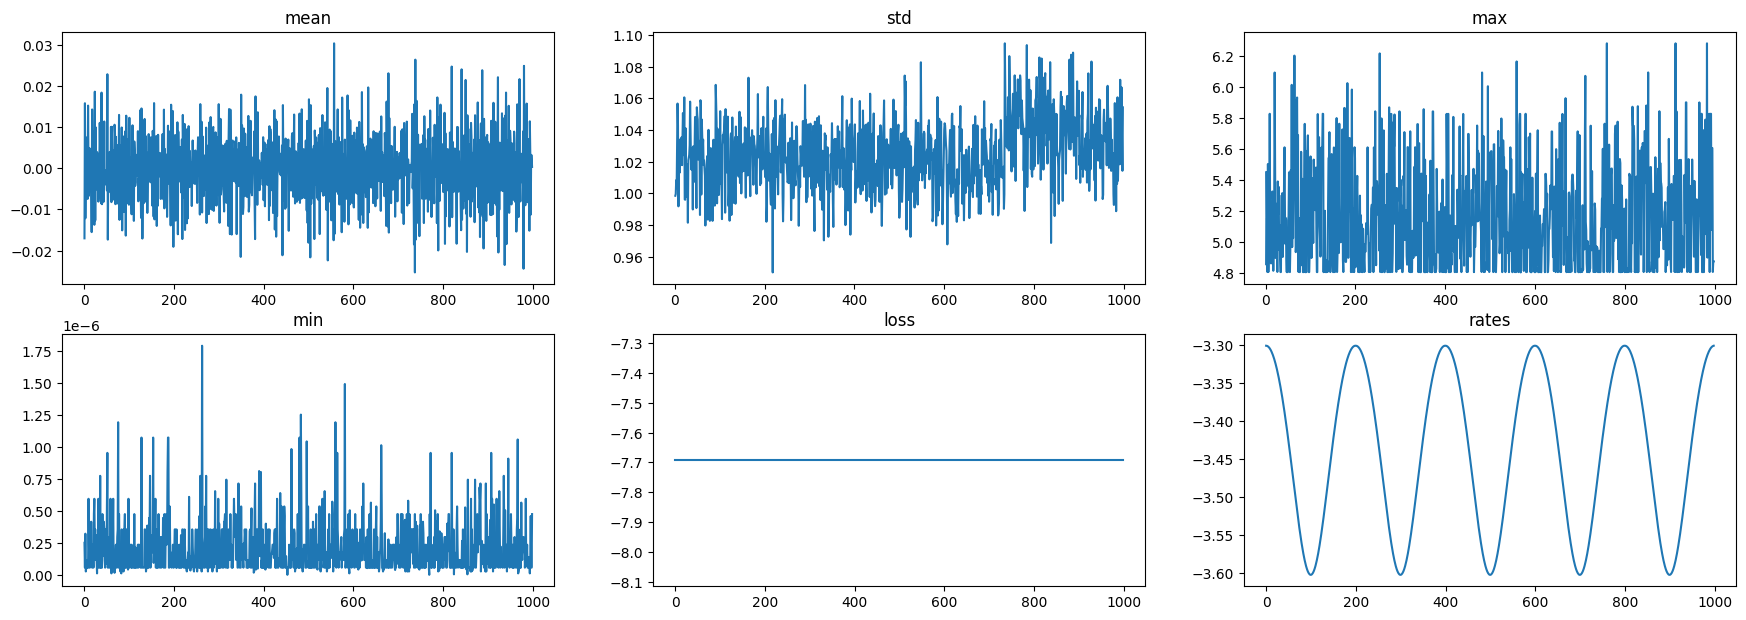

In [40]:
stats, losses, rates = run()
plot(stats, ['mean', 'std', 'max', 'min'], 3, 720, 2160, True)

In [41]:
model(inputs)[:, :3].detach().transpose(0, 1).cpu().round()

tensor([[[-15.],
         [-12.],
         [ -9.],
         [ -6.],
         [ -3.],
         [  0.],
         [  3.],
         [  6.],
         [  9.],
         [ 12.]],

        [[-15.],
         [-12.],
         [ -9.],
         [ -6.],
         [ -3.],
         [  0.],
         [  3.],
         [  6.],
         [  9.],
         [ 12.]],

        [[-15.],
         [-12.],
         [ -9.],
         [ -6.],
         [ -3.],
         [  0.],
         [  3.],
         [  6.],
         [  9.],
         [ 12.]]])

In [42]:
test_inputs = torch.arange(inp_num, device=DEVICE, dtype=DTYPE
).reshape(inp_num, 1).unsqueeze(1).expand(inp_num, len(genomes), 1) + 10
test_outputs = test_inputs * 3
test_inputs[:, 0].T, test_outputs[:, 0].detach().T

(tensor([[10., 11., 12., 13., 14., 15., 16., 17., 18., 19.]], device='cuda:0'),
 tensor([[30., 33., 36., 39., 42., 45., 48., 51., 54., 57.]], device='cuda:0'))

In [43]:
model(test_inputs)[:, 0].detach().transpose(0, 1).cpu().round(decimals=0)

tensor([[30., 33., 36., 39., 42., 45., 48., 51., 54., 57.]])